# CSCI 4831 Project: Implementing Shor's Algorithm

### Al Haddad, Jeremy Huang, Daniel Zhu

## Abstract

Shor's algorithm, proposed by Peter Shor in 1994, is a quantum algorithm for integer factorization. It has garnered significant attention due to its potential to efficiently factor large composite numbers, which forms the basis of modern encryption techniques such as RSA. This project aims to implement Shor's algorithm using quantum computing techniques and classical preprocessing methods. The implementation will involve modular exponentiation and the quantum Fourier transform (QFT) as the key components of the algorithm. Additionally, classical components such as number theory algorithms and classical post-processing steps will be integrated to enhance the efficiency and accuracy of the algorithm. This project will be implemented using the quantum programming framework Qiskit.

## Introduction

In our modern world, we send vast quantities of data across the internet which we would rather keep private. Whether it’s our banking information for online purchases, personal messages between friends, or even our identification(SSN/address). Obviously, we don’t want this data to be accessed by others which is why we encrypt this data before sending it.  Modern RSA encryption algorithms rely on the intentionally computationally difficult problem of prime number factoring. This computational complexity allows for secure keys that can safely transmit data without fear of uncovering its contents. Shor’s Algorithm subverts these computation requirements and improves from exponential to polynomial time complexity, trivializing many complex cybersecurity ciphers. Shor’s Algorithm could present an opportunity for a “Quantum arms race”, in which the first country to implement such an algorithm successfully could access vast quantities of encrypted data. In addition to revolutionizing cybersecurity, prime factorization has remained a difficult task for other mathematical problems and research. Additionally, the Quantum Fourier Transform is pivotal in quantum algorithms such as quantum phase estimation, quantum simulation, and quantum error correction. In phase estimation algorithms, the QFT enables precise determination of quantum state phases, vital for applications like quantum chemistry simulations and solving linear systems. Additionally, the QFT is integral to quantum error correction, where it aids in encoding, manipulating, and decoding quantum information to mitigate errors induced by noise and decoherence, ensuring the reliability of quantum computations. 


## Big Picture of Shor's Algorithm

We wish to factor $N = pq$, where $p$ and $q$ are prime.  In this case, finding a proper factor (not $1$ or $N$) of $N$ is equivlent to factoring $N$.  (If we find one factor, then you get the other factor by dividing.)

Shor's algorithm is based on a familiar principle of factoring.  We seek a "surprise square root" of $1$, essentially an $x$ such that $x^2 \equiv 1 \pmod{N}$ but $x \not\equiv \pm 1 \pmod{N}$.  Then taking $\gcd(x \pm 1,N)$ gives a proper factor. 

To begin the algorithm, we can find the multiplicative order of $\alpha$ modulo $N$, that is $\alpha^r \equiv 1 \pmod{N}$. If that order $r$ is even, we *might* be lucky enough to have found a "surprise square root", due to the following:

$$ \alpha^r \equiv 1 \pmod{N} $$
$$ (\alpha^{r/2})^2 \equiv 1 \bmod N \quad \text{since $r$ is even}$$
$$ (\alpha^{r/2})^2 - 1 \equiv 0 \bmod N $$
$$ (\alpha^{r/2} + 1)(\alpha^{r/2} - 1) \equiv 0 \bmod N $$

So, we see that the product $(\alpha^{r/2} + 1)(\alpha^{r/2} - 1)$ is an integer multiple of $N$, the number to be factored. So, if neither $(\alpha^{r/2} + 1)$ or $(\alpha^{r/2} - 1)$ are themselves multiple of $N$, then each of them has to contain a exactly one proper factor of $N$, which could be exctracted using the greatest common divisor.

For example, if we take $N = 143 = 11\cdot 13$ and $\alpha = 21$, we can calculate that $21^4 \equiv 1\pmod{143}$, so we would have $r = 4$. Now, let us consider $21^{4/2} = 441 \equiv 12 \pmod{143}$. Note that $12^2 = 144 \equiv 1 \pmod{143}$. So, we see that $12$ is a "surprise square root" modulus $143$. Now, we take $\gcd(12-1,143) = 11$ or $\gcd(12+1,143) = 13$, both of which are proper factors of $143$.


The resulting algorithm is like this:


1. **Classical step:**  Take a random $\alpha \in \mathbb{Z}/N\mathbb{Z}$. Check that $\gcd(\alpha,N) = 1$.  If not, the result would be a proper factor of $N$.
2. **Quantum step:**  Find the multiplicative order of $\alpha$, $r$, which is also the period of the function $f(x) = \alpha^x$ taking values in $\mathbb{Z}/N\mathbb{Z}$.
3. **Classical step:**  Check and see if $r$ is even, and if $\alpha^{r/2} \not\equiv \pm 1 \pmod{N}$.  If not, return to first step.
4. **Classical step:**  Compute $\gcd(\alpha^{r/2}-1,N)$, which is a proper factor of $N$, as explained above.


## Classical Implementation

Here, we will run a classical algorithm to calculate the order, or period of our exponentiation function. In practice, this is very inefficient (exponential runtime), and is what the Quantum Computer would calculate. 

In [2]:
import math, random

def find_period(x, N): #Finding the Period through Brute Force
    n = 1
    t = x
    while t != 1:
        t *= x
        t %= N
        n += 1
    return n


N = 143
while (True):
    a =  random.randint(1,N-1)
    if (math.gcd(a,N) != 1):
        print(N, "has factor:", math.gcd(a,N), "from calculating the greates common divisor between", a, "and", N)
        break
    else:
        r = find_period(a,N)
        if (r % 2 == 0 and pow(a,int(r/2),N) != 1 and pow(a,int(r/2),N) != N-1):
            factor = math.gcd(pow(a,int(r/2),N) - 1, N)
            print(N, "has factor", factor, "from calculating the greatest common divisor between", pow(a,int(r/2),N) - 1, "and", N)
            break

143 has factor 11 from calculating the greatest common divisor between 11 and 143


## Quantum Period Finding

Daniel and Al

### Continued Fractions

The final problem in period finding is to get $r$ from a value $y$ close to $\frac{sm}{r}$, which we got from our QFT. The value $y$ we measure is really telling us that the value $\frac{y}{m}$ is close to the "real QFT spike" $ \frac{sm}{r}$. So the challenge is to guess a rational number $\frac{sm}{r}$ that is close to $\frac{y}{m}$ such that the difference

$$\left| \frac{sm}{r} - \frac{y}{m} \right| $$

is small. More specifically, we want to find such rational numbers where $r$ is small. The continued fraction algorithm gives all rational approximations $\frac{p}{q}$ to a random number $x$ such that $|x - \frac{p}{q}| < \frac{1}{2q^2}$, in polynomial time. To perform this algorithm, what we do is repeatedly taking out the integer part of a fraction and inverting. For example, if $x = \frac{9}{16}$

$$ \frac{9}{16} = 0 + \frac{9}{16} = 0 + \frac{1}{ \frac{16}{9} } = 0 + \frac{1}{1 +  \frac{7}{9} } = 0 + \frac{1}{1 + \frac{1}{ \frac{9}{7} }} = 0 + \frac{1}{1 + \frac{1}{ 1 + \frac{2}{7} }} = 0 + \frac{1}{1 + \frac{1}{ 1 + \frac{1}{\frac{7}{2}} }} = 0 + \frac{1}{1 + \frac{1}{ 1 + \frac{1}{3 + \frac{1}{2}} }} $$

With our continued fraction expansion, we can get good rational approximations that satisfy the criteria mentioned above by "truncating it" (taking away terms in the bottom right). For example, using our continued fraction expansion of $\frac{9}{16}$, the truncations would be:

$$0 , \frac{1}{1} , \frac{1}{1 + \frac{1}{1}}, \frac{1}{1 + \frac{1}{1 + \frac{1}{3}}}, \frac{1}{1 + \frac{1}{1 + \frac{1}{3 + \frac{1}{2}}}} $$

Each of these can be simplified into:

$$0, 1, \frac{1}{2}, \frac{4}{7}, \frac{9}{16} $$

which are the good rational approximations to $\frac{9}{16}$. So, now we have the "guesses" for $r$, which are the denominators of those approximations, which are $r = 1,2,7,16$. We could then test these numbers if they're the true order, by seeing if they actually do satisfy the property $\alpha^r \equiv 1 \pmod{N}$. Below is a function that calculates these approximations and "guesses" for $r$, given a fraction $\frac{y}{m}$.


In [3]:
def continued_fraction_to_convergents(y, m): #Something's wrong, will fix later - Jeremy
    convergents = []
    a = y // m
    p0, p1 = a, a * y + m
    q0, q1 = 1, y

    convergents.append((p0, q0))
    convergents.append((p1, q1))

    while True:
        a = q1 // m
        p2 = a * p1 + p0
        q2 = a * q1 + q0
        convergents.append((p2, q2))

        if q2 == 1:
            break

        p0, p1 = p1, p2
        q0, q1 = q1, q2

    return convergents

y = 9
m = 16
convergents = continued_fraction_to_convergents(y, m)
print("Convergents of", y, "/", m, "are:")
for i, (p, q) in enumerate(convergents):
    print("Convergent", i+1, ":", p, "/", q)


Convergents of 9 / 16 are:
Convergent 1 : 0 / 1
Convergent 2 : 16 / 9
Convergent 3 : 0 / 1


## Quantum Implementation

In Qiskit

Daniel and Al

The quantum implementation of Shor's consists of two distinct steps: modular exponentiation and the Quantum Fourier Transform (in addition to some hadamards) to superpose the 0 kets.

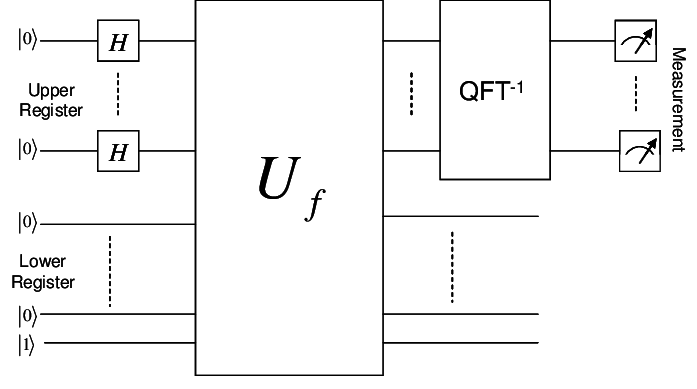

Before we can do either of these things, we need to determine the number of qubits to put in our upper and lower register. We choose a T value in the range $$T ∈ [N^2, 2N^2] ∋ T = 2^t$$
We then prepare our upper register with $t$ qubits and our bottom register with $\log_2{N}$ qubits.

In [37]:
from qiskit import *
t = math.floor(math.log(2*(N*N),2))
q = QuantumRegister(t, 'q')
c = ClassicalRegister(math.ceil(math.log(N,2)), 'c')

shor = QuantumCircuit(q, c)

for qubit in range(t):
    shor.h(qubit)

shor.draw()

25


┌───┐
 q_0: ┤ H ├
      ├───┤
 q_1: ┤ H ├
      ├───┤
 q_2: ┤ H ├
      ├───┤
 q_3: ┤ H ├
      ├───┤
 q_4: ┤ H ├
      ├───┤
 q_5: ┤ H ├
      ├───┤
 q_6: ┤ H ├
      ├───┤
 q_7: ┤ H ├
      ├───┤
 q_8: ┤ H ├
      ├───┤
 q_9: ┤ H ├
      ├───┤
q_10: ┤ H ├
      ├───┤
q_11: ┤ H ├
      ├───┤
q_12: ┤ H ├
      ├───┤
q_13: ┤ H ├
      ├───┤
q_14: ┤ H ├
      └───┘
 c: 8/═════

####  Modular Exponentiation (Taken from Qiskit Tutorial)

The modular exponentiation is the evaluation of $x^a \bmod N$ for $2^t$ values of $a$ in parallel, is the most demanding part of the algorithm. This can be performed using the following identity for the binary representation of any integer: $x = x_{t-1}2^{t-1} + ... x_12^1+x_02^0$, where $x_t$ are the binary digits of $x$. From this, it follows that:

\begin{aligned}
x^a \bmod N & = x^{2^{(t-1)}a_{t-1}} ... x^{2a_1}x^{a_0} \bmod N \\
& = x^{2^{(t-1)}a_{t-1}} ... [x^{2a_1}[x^{2a_0} \bmod N] \bmod N] ... \bmod N \\
\end{aligned}

This means that 1 is first multiplied by $x^1 \bmod N$ if and only if $a_0 = 1$, then the result is multiplied by $x^2 \bmod N$ if and only if $a_1 = 1$ and so forth, until finally the result is multiplied by $x^{2^{(s-1)}}\bmod N$ if and only if $a_{t-1} = 1$. 

Therefore, the modular exponentiation consists of $t$ serial multiplications modulo $N$, each of them controlled by the qubit $a_t$. The values $x,x^2,...,x^{2^{(t-1)}} \bmod N$ can be found efficiently on a classical computer by repeated squaring.

In [34]:
# Quantum Modular Exponentiation function - Daniel Zhu (Working on it o-o)
# a: Our guess number
# power: IDK what this means
# Return: Condensed Gate

# def find_period_quantum(a, power):
#     return

# This is just my experiements
for i in range(t - 1, 2, -1):
    shor.swap(i, i - 1)

print(shor)

     ┌───┐               
q_0: ┤ H ├───────────────
     ├───┤               
q_1: ┤ H ├───────────────
     ├───┤               
q_2: ┤ H ├─────────────X─
     ├───┤             │ 
q_3: ┤ H ├──────────X──X─
     ├───┤          │    
q_4: ┤ H ├───────X──X────
     ├───┤       │       
q_5: ┤ H ├────X──X───────
     ├───┤    │          
q_6: ┤ H ├─X──X──────────
     ├───┤ │             
q_7: ┤ H ├─X─────────────
     └───┘               
c: 8/════════════════════
                         


## Results